# 🩺 Predict the Onset of Diabetes Based on Diagnostic Data

**1]  What is supervised machine learning?**

--> Suppervised machine learning is traning model on labeled data which you already know
    the target column.
    
**there is Two types of supervised machine learning**

1] **Regression** --> it used to predict contineous numeric values.

2] **Classification** --> it used to predict categorical values

---

**2]  Where is it best used?**

--> Supervised machine learning works best when you have historical data with known outcomes and you want to predict future outcomes based on that.

**real world examples :** 

*    **Healthcare** --> predicting whether a patient has a disease based on diagnostic test results.
*    **Banking**    --> predicting whether a loan applicant will default or not.

---

**3]  What kind of dataset does it need?**

--> Supervised machine learning needs a labeled dataset — meaning the data must have both input features and a target output column.

**For example :**

*  **Input features (X)** --> the measurements or variables used for prediction (age, glucose level, BMI etc.)

*  **Target column (Y)** --> the correct answer the model needs to learn to predict (diabetic or not — 0 or 1)

In [2]:
# Importing necessary libraries
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

---
### Step 1 — Load the Dataset

--> First step is to read the dataset into a pandas dataframe 
    so we can start exploring and understanding the data.
---

In [3]:
df = pd.read_csv("diabetes.csv")

---
### Step 2 — Basic Data Exploration

--> Before doing anything we need to understand what we are 
    working with Let's look at the structure of the dataset.
---

In [4]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


**Shape — Dimensions of the dataset**

--> Shape tells us how many rows (patients) and columns 
    (features) are present in the dataset.

In [5]:
print("Shape of dataset :", df.shape)

Shape of dataset : (768, 9)


**observation :**

--> dataset contains **768 rows** and **9 columns**
    means 768 patients with 8 input features 
    and 1 target column.

---
**Info — Column types and null values**

--> info gives us the data type of each column and 
    whether any null values exist.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


---
**observation :**

* all columns are numeric — float64 or int64
* no null values found at this stage
* but this does not mean data is clean —
  zero values may be hiding missing data 
  in some medical columns

---

**Describe — Statistical Summary**

--> before looking at model lets first check the data 
    have any issues like zero values in medical columns.
    
--> describe() gives us count, mean, std, min, max and 
    percentile values for each column.

---

In [7]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


**what i found :**

* **Glucose** min = 0       --> impossible for living person 
* **BloodPressure** min = 0 --> 0 blood pressure means dead 
* **SkinThickness** min = 0 --> physically not possible 
* **Insulin** min = 0       --> body always produce some insulin 
* **BMI** min = 0           --> 0 body mass is not possible 

* **Pregnancies** min = 0   --> valid, woman can have 0 pregnancies ✓
* **Age** min = 21          --> valid ✓
* **DiabetesPedigreeFunction** min = 0.078 --> valid ✓

**about these zeros :**

--> these are not real zero values, they are missing values
    that were recorded as zero during data collection.
    we need to fix these before doing any analysis.

**Outcome mean = 0.35 :**

--> this is telling us roughly 65% patients are non-diabetic
    and 35% are diabetic.
    this is class imbalance which we will handle later 
    during modeling.

--> **next step is to replace these impossible zeros 
    with NaN and fill with median.**

---
### Step 3 — Data Cleaning

--> now we know which columns have impossible zero values.
    lets fix them before we do any analysis.
---

---

**Check Zero Values in Medical Columns**

--> first lets count exactly how many zeros are 
    present in each medical column.
    
**columns where zero is impossible :**

* Glucose       --> person with 0 glucose cannot be alive
* BloodPressure --> 0 blood pressure means no heartbeat
* SkinThickness --> 0 skinfold is physically impossible
* Insulin       --> body always produces some insulin
* BMI           --> 0 body mass means no body — impossible

In [8]:
# checking zero count in medical columns
medical_cols = ['Glucose', 'BloodPressure',
                'SkinThickness', 'Insulin', 'BMI']

print("zero value count in medical columns :")
print((df[medical_cols] == 0).sum())

zero value count in medical columns :
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


**observation :**

--> we can clearly see zeros exist in all 5 medical columns.
    these are not real values — they are missing data 
    entered as zero during data collection.

---

**Replace Zeros with NaN and Fill with Median**

--> we will replace these impossible zeros with NaN first,
    then fill them with the median of each column.

**why median and not mean ?**

--> Insulin column has extreme values up to 846.
    mean would be pulled upward by those extreme values.
    median is more robust and gives realistic replacement value.

In [9]:
medical_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin','BMI']

for i,col in enumerate(medical_cols):
    
    # replacing zeros with NaN
    df[col] = df[col].replace(0, np.nan)
        
    # filling NaN with median of each column
    df[col] = df[col].fillna(df[col].median())
    
# verify no zeros remain
print("zero count after cleaning :")
print((df[medical_cols] == 0).sum())

zero count after cleaning :
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64


**observation :**

--> all zeros in medical columns are now replaced 
    with median values.
    data is now clean and ready for analysis.

---

---
### Step 4 — Outlier Detection and Treatment

--> now that data is clean lets check for outliers.
    outlier is a value that is very different 
    from the rest of the data.
---

**Visualize Outliers Using Boxplots**

--> boxplot shows us the distribution of each column and
    highlights any values that fall far outside normal range.
    
--> the dots outside the whiskers are the outliers.

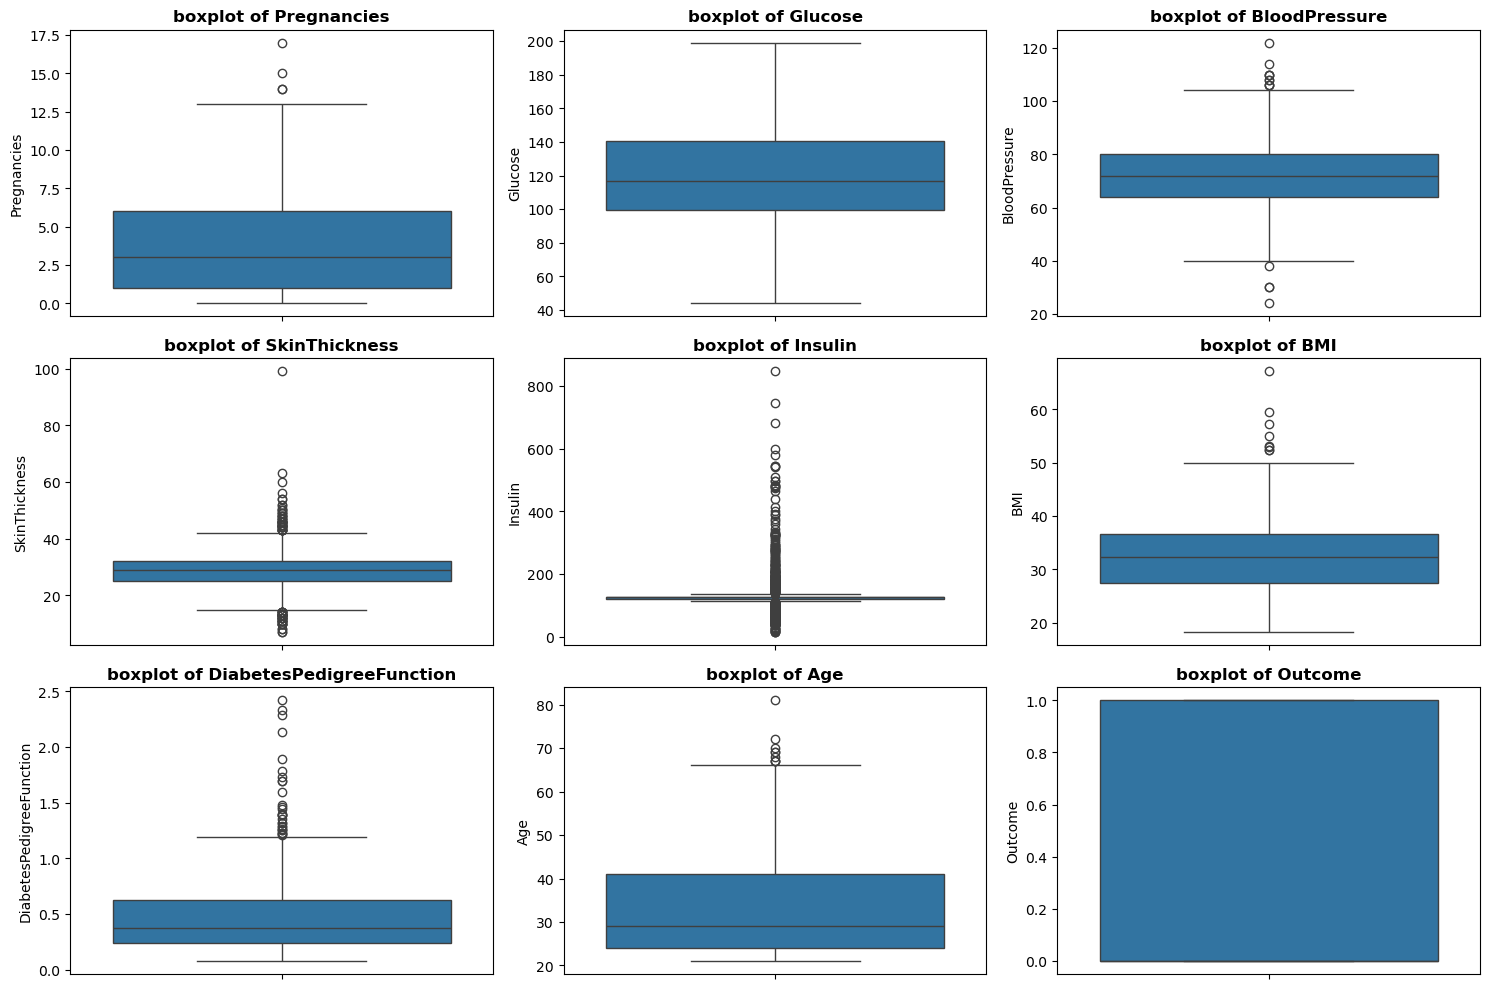

In [10]:
cols=  ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin','BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
fig,axes=plt.subplots(3,3,figsize=(15,10))
axes=axes.flatten()
for i,col in enumerate(cols):
    sns.boxplot(y=df[col],ax=axes[i])
    axes[i].set_title(f"boxplot of {col}",fontweight="bold")
plt.tight_layout()  
plt.show()

**observation from boxplots :**

* **Pregnancies**            --> outliers at 15-17, 
                                 rare but medically possible ✓
* **Glucose**                --> slight low outlier, 
                                 already handled in cleaning ✓
* **BloodPressure**          --> low outlier at 24, 
                                 possible in real patients ✓
* **SkinThickness**          --> one extreme value near 99, 
                                 need to investigate this
* **Insulin**                --> multiple outliers above 600, 
                                 need to investigate these
* **BMI**                    --> outliers above 50-60, 
                                 morbid obesity is real ✓
* **DiabetesPedigreeFunction** --> outliers up to 2.42, 
                                   valid family history scores ✓
* **Age**                    --> one patient aged 81, 
                                 completely valid ✓

**Investigate Insulin Outliers (600+)**

--> rather than blindly removing these values lets look 
    at each row individually and decide based on 
    what other columns are saying.

In [11]:
# checking rows with Insulin >= 600
df[df['Insulin'] >= 600]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
13,1,189.0,60.0,23.0,846.0,30.1,0.398,59,1
228,4,197.0,70.0,39.0,744.0,36.7,2.329,31,0
247,0,165.0,90.0,33.0,680.0,52.3,0.427,23,0
584,8,124.0,76.0,24.0,600.0,28.7,0.687,52,1


**row by row decision :**

* **row 13**  --> Glucose 189, BMI 30.1, Age 59, Outcome 1
               --> high glucose + older age + diabetic 
               --> everything consistent --> **KEEP** 

* **row 228** --> Glucose 197, BMI 36.7, DPF 2.329, Outcome 0
               --> very high glucose + strong family history
               --> borderline diabetic case 
               --> **KEEP** 

* **row 247** --> Glucose 165, BMI 52.3, Age 23, Outcome 0
               --> morbidly obese young patient
               --> severe insulin resistance is possible
               --> **KEEP** 

* **row 584** --> Glucose 124, BMI 28.7, Age 52, Outcome 1
               --> confirmed diabetic patient
               --> **KEEP** 

--> **all 4 rows retained as medically genuine cases**

---

In [12]:
# checking rows with SkinThickness > 80
df[df['SkinThickness'] > 80]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
579,2,197.0,70.0,99.0,125.0,34.7,0.575,62,1


In [13]:
# replace that single row SkinThickness with median
median_skin = df['SkinThickness'].median()
df.loc[579, 'SkinThickness'] = median_skin

print("SkinThickness of row 579 updated to :", median_skin)

# verify
df.loc[[579]]

SkinThickness of row 579 updated to : 29.0


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
579,2,197.0,70.0,29.0,125.0,34.7,0.575,62,1


**SkinThickness outlier — row 579 :**

--> found one extreme value of 99 in SkinThickness column.
    checked the full row to verify if it makes sense.
    
* SkinThickness = 99 --> extreme value
* BMI = 34.7         --> only obese class 1, not extreme

--> for SkinThickness of 99 to be genuine, 
    BMI should be atleast 45+.
    BMI of 34.7 and SkinThickness of 99 
    are contradicting each other.
    
--> this looks like a data entry error.
    replaced with column median value.

---
**Verify Data After All Cleaning**

--> now that we have handled all the issues lets do 
    a final check to make sure everything looks good
    before we move to EDA.

In [14]:
# final shape check
print("final shape of dataset :", df.shape)

final shape of dataset : (768, 9)


**observation :**

--> dataset still has **768 rows** and **9 columns**.
    we did not remove any rows —
    only replaced incorrect values with median.
    every patient record is still intact. ✓

In [15]:
# final describe to confirm
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.656250,72.386719,29.016927,140.671875,32.455208,0.471876,33.240885,0.348958
std,3.369578,30.438286,12.096642,8.420715,86.383060,6.875177,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,121.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,63.000000,846.000000,67.100000,2.420000,81.000000,1.000000


**observation :**

--> after all cleaning :

* **Glucose** min = 44       --> no zeros 
* **BloodPressure** min = 24 --> no zeros 
* **SkinThickness** max is now fixed --> no 99 value 
* **Insulin** min = 14       --> no zeros 
* **BMI** min = 18.2         --> no zeros 

--> data is now clean and ready for EDA.
    all impossible values are handled.
    no rows were deleted.

In [16]:
# final zero check
print("final zero check in medical columns :")
print((df[medical_cols] == 0).sum())

final zero check in medical columns :
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64


**observation :**

--> zero count is 0 in all medical columns.
    data cleaning is complete. ✓

---
**summary of all cleaning done :**

1]  replaced zeros with median in 5 medical columns
    --> Glucose, BloodPressure, SkinThickness, 
        Insulin, BMI

2]  investigated 4 rows with Insulin >= 600
    --> all 4 retained as medically genuine cases

3]  investigated 1 row with SkinThickness = 99
    --> BMI was only 34.7 which contradicts 99 skinfold
    --> replaced with column median

4]  no rows were deleted from dataset
    --> domain knowledge used instead of 
        blind statistical methods

--> **dataset is now clean. moving to EDA.**
---

---
## 📊 Step 5 — Exploratory Data Analysis (EDA)

--> now data is clean and outliers are handled.
    lets explore the data visually to understand 
    patterns and relationships between features.
---

---
**Distribution of Each Feature**

--> histogram shows us how values are spread 
    across each column.
    
--> this helps us understand the shape of data —
    is it normal, skewed or uniform ?

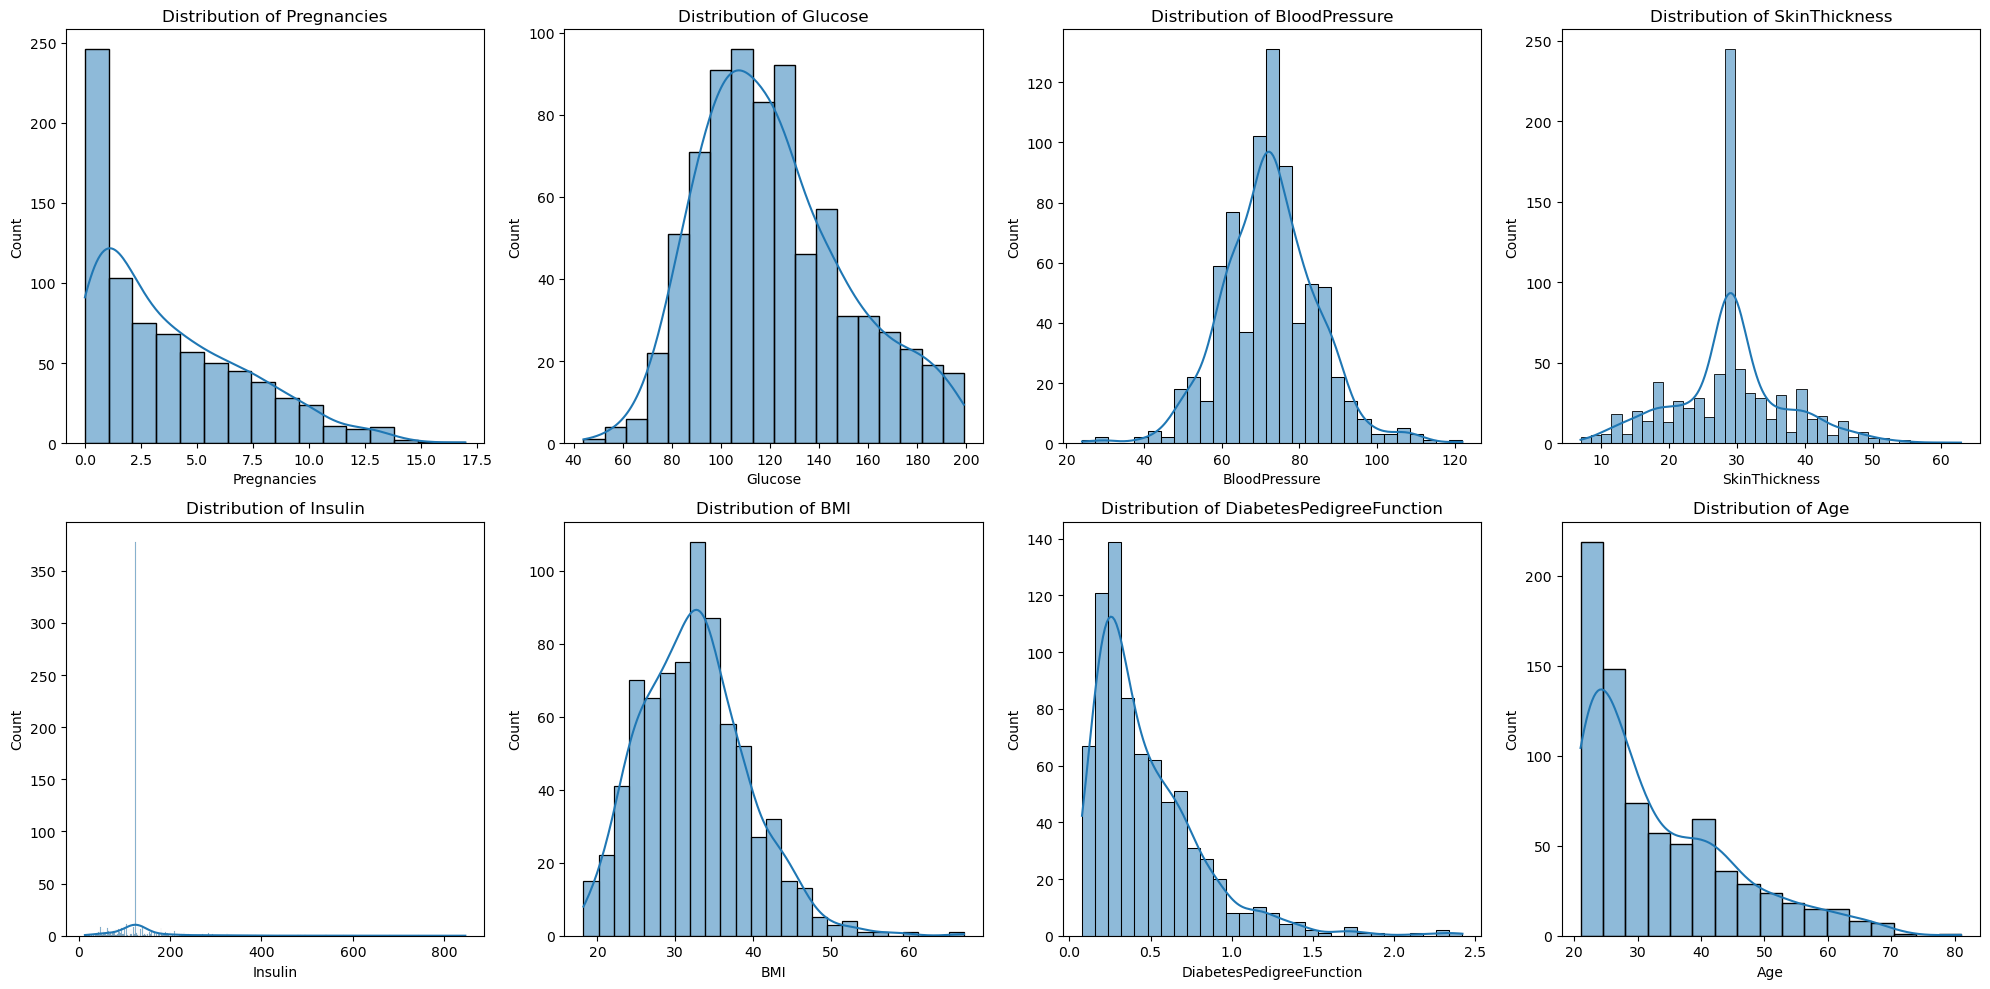

In [17]:
num_cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 
            'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
plt.tight_layout()
plt.show()

**observation :**

* **Pregnancies**            --> right skewed. most patients 
                                 have 0-3 pregnancies
                                 
* **Glucose**                --> roughly bell shaped, centered 
                                 around 100-130 mg/dL. most 
                                 normally distributed feature ✓
                                 
* **BloodPressure**          --> normal distribution centered 
                                 around 60-80 mmHg
                                 
* **SkinThickness**          --> right skewed, most values 
                                 between 20-40mm
                                 
* **Insulin**                --> heavily right skewed. majority 
                                 below 200, very few extreme values.
                                 confirms high variance
                                 
* **BMI**                    --> roughly normal, centered around 
                                 30-35. population leans towards 
                                 overweight range
                                 
* **DiabetesPedigreeFunction** --> strongly right skewed. most 
                                   patients have low family 
                                   history score below 0.5
                                   
* **Age**                    --> right skewed. majority between 
                                 21-35 years old
                                 
* **Outcome**                --> confirms class imbalance. 
                                 non-diabetic cases are nearly 
                                 double the diabetic cases

---
**Class Imbalance Check**

--> before modeling its important to understand how balanced 
    the target column is between the two classes.

Outcome
0    500
1    268
Name: count, dtype: int64


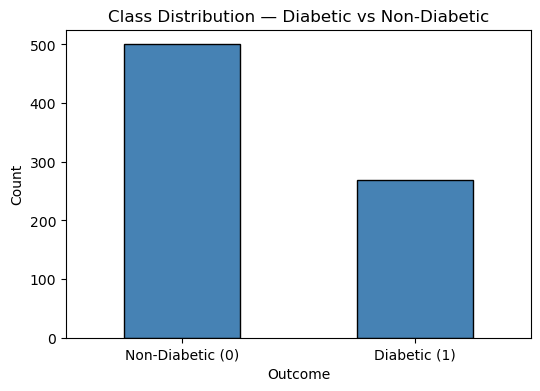

In [18]:
outcome_counts = df['Outcome'].value_counts()
print(outcome_counts)

plt.figure(figsize=(6,4))
ax = df['Outcome'].value_counts().plot(kind='bar',
                                        color='steelblue',
                                        edgecolor='black')
plt.title('Class Distribution — Diabetic vs Non-Diabetic')
ax.set_xticklabels(['Non-Diabetic (0)', 'Diabetic (1)'],
                    rotation=0)
plt.ylabel('Count')
plt.show()

**observation :**

* **Non-Diabetic (0)** --> 500 patients --> 65%
* **Diabetic (1)**     --> 268 patients --> 35%

--> dataset is moderately imbalanced.
    model may develop bias towards predicting non-diabetic
    just because that class is more in number.

--> **solution : will use class_weight='balanced' during 
    model training to give equal importance to both classes.**

---
**Correlation Heatmap**

--> correlation tells us how strongly each feature is 
    related to the Outcome and to each other.

* values close to **+1** --> strong positive relationship
* values close to **0**  --> no relationship
* values close to **-1** --> strong negative relationship

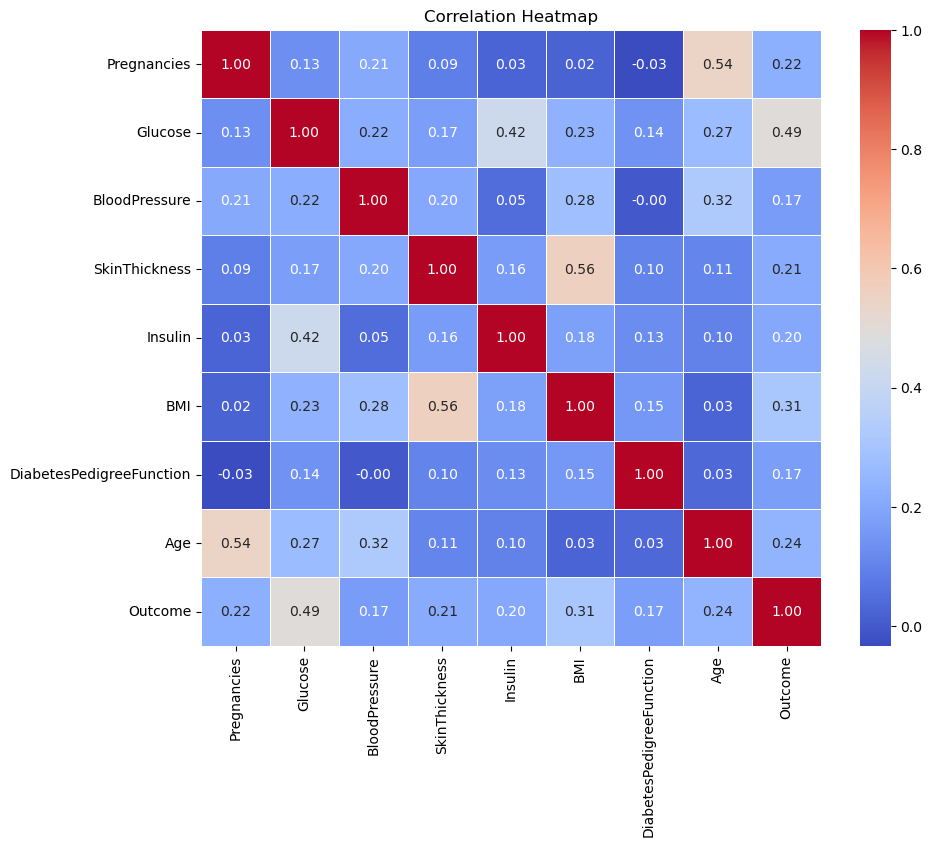

In [19]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(),
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

**observation :**

**features vs Outcome :**

* **Glucose → Outcome (0.49)**             --> strongest predictor 
* **BMI → Outcome (0.31)**                 --> second strongest
* **Age → Outcome (0.24)**                 --> meaningful relationship
* **Pregnancies → Outcome (0.22)**         --> mild relationship
* **DiabetesPedigreeFunction → Outcome (0.17)** --> weak but present
* **BloodPressure → Outcome (0.17)**       --> weakest predictor

**features vs features :**

* **SkinThickness and BMI (0.54)** --> both measure body fat 
  indirectly so this correlation makes medical sense
  
* **Insulin and Glucose (0.42)**   --> higher glucose triggers 
  higher insulin production — medically expected
  
* no two input features exceed 0.6 correlation -->
  no multicollinearity concern -->
  all features are safe to use in model ✓

---
**Feature Distribution by Outcome**

--> comparing each feature between diabetic and non-diabetic 
    groups helps us understand which features actually 
    separate the two classes.

C:\Users\athar\AppData\Local\Temp\ipykernel_14832\1608577267.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot([df[df['Outcome']==0][feature],
C:\Users\athar\AppData\Local\Temp\ipykernel_14832\1608577267.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot([df[df['Outcome']==0][feature],
C:\Users\athar\AppData\Local\Temp\ipykernel_14832\1608577267.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot([df[df['Outcome']==0][feature],
C:\Users\athar\AppData\Local\Temp\ipykernel_14832\1608577267.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been 

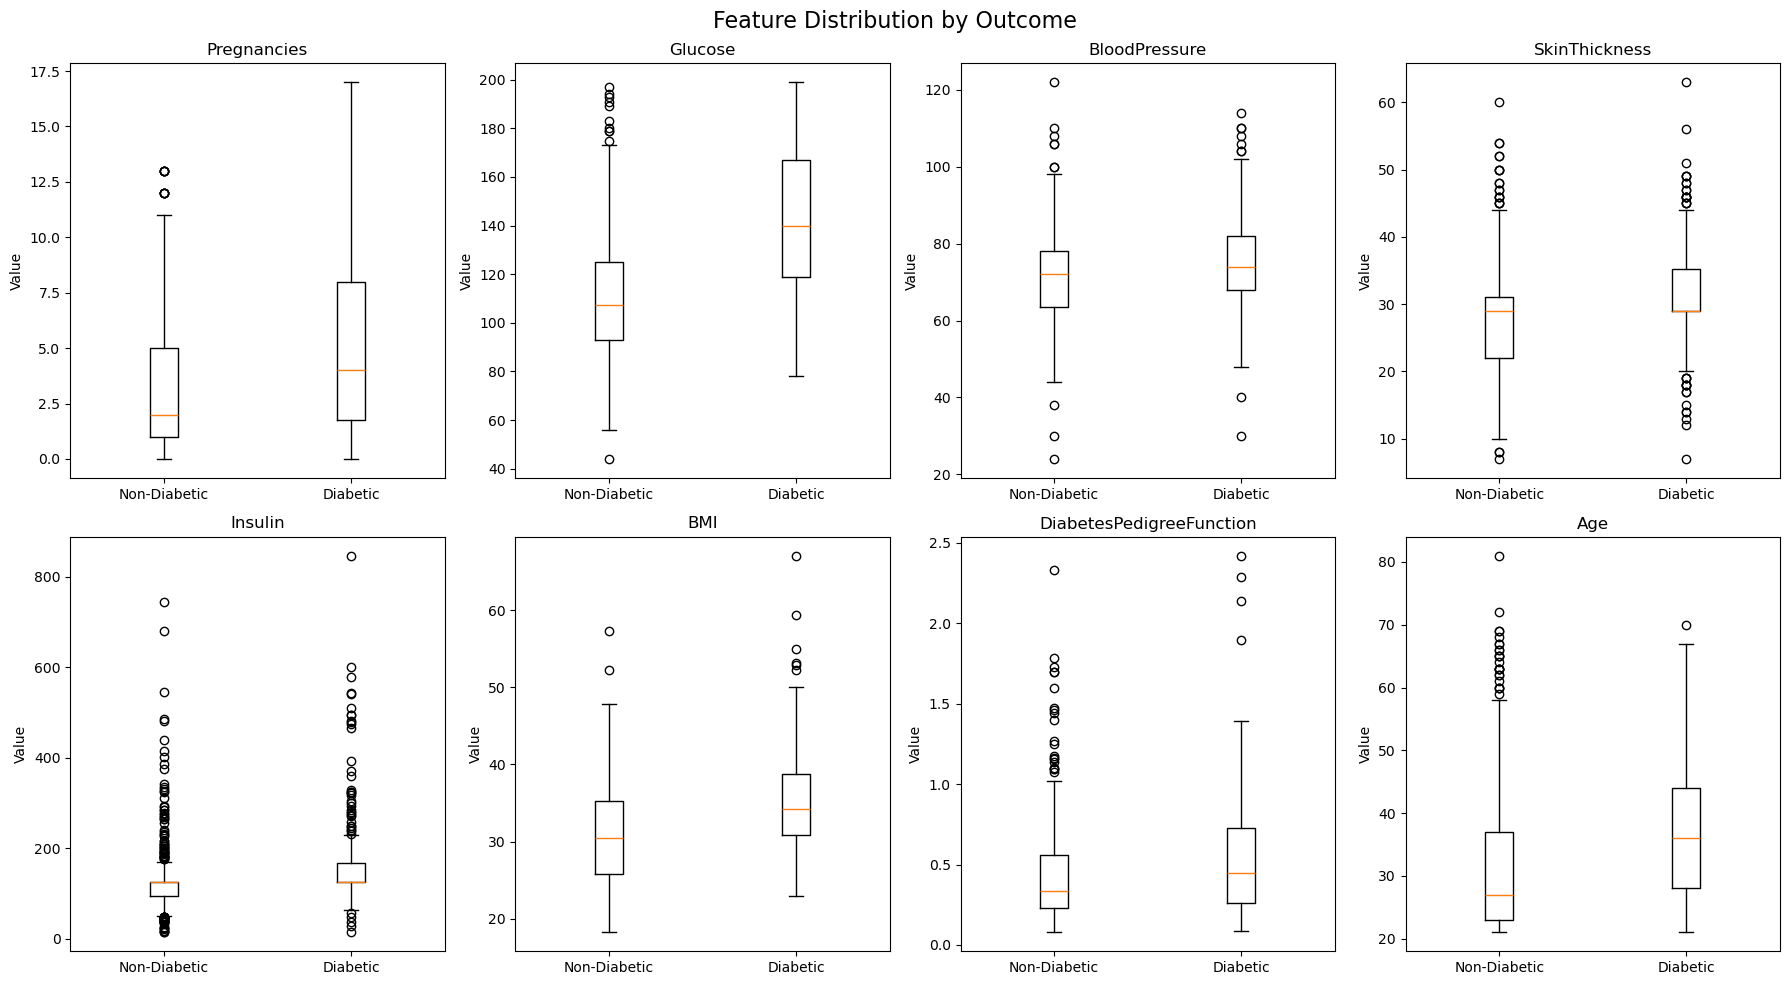

In [20]:
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

features = ['Pregnancies', 'Glucose', 'BloodPressure',
            'SkinThickness', 'Insulin', 'BMI',
            'DiabetesPedigreeFunction', 'Age']

for i, feature in enumerate(features):
    axes[i].boxplot([df[df['Outcome']==0][feature],
                     df[df['Outcome']==1][feature]],
                    labels=['Non-Diabetic', 'Diabetic'])
    axes[i].set_title(feature)
    axes[i].set_ylabel('Value')

plt.suptitle('Feature Distribution by Outcome', fontsize=16)
plt.tight_layout()
plt.show()

**observation :**

* **Glucose**    --> clearest separation between groups.
                     diabetic median ~140 vs non-diabetic ~110.
                     most distinguishable feature ⭐

* **BMI**        --> diabetic patients show higher median BMI (~35)
                     vs non-diabetic (~30). clear upward shift visible

* **Age**        --> diabetic patients tend to be older.
                     median age ~36 for diabetic vs ~27 for non-diabetic

* **Pregnancies** --> slight upward shift for diabetic group.
                      possibly linked to gestational diabetes history

* **BloodPressure** --> almost no visible difference between groups.
                        median values nearly identical --> weak predictor confirmed

* **Insulin**    --> both groups overlap heavily with high variance.
                     difficult to distinguish groups on insulin alone

* **DiabetesPedigreeFunction** --> slight upward shift for diabetic
                                    but significant overlap between groups

* **SkinThickness** --> minimal difference between groups,
                        similar pattern to BloodPressure

---
**Glucose vs BMI Scatter Plot**

--> scatter plot helps us visualize two features together
    and see how they jointly relate to the Outcome.

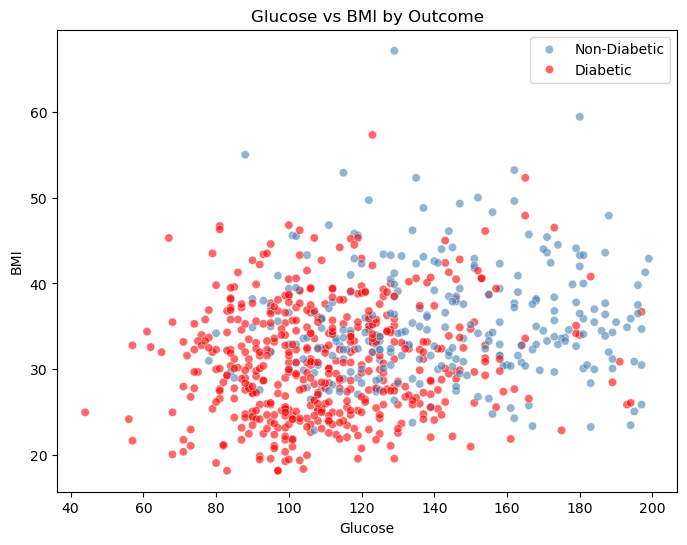

In [21]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='Glucose',
                y='BMI',
                hue='Outcome',
                data=df,
                palette={0:'red', 1:'steelblue'},
                alpha=0.6)
plt.title('Glucose vs BMI by Outcome')
plt.xlabel('Glucose')
plt.ylabel('BMI')
plt.legend(labels=['Non-Diabetic', 'Diabetic'])
plt.show()

**observation :**

* diabetic patients (blue) concentrate heavily in 
  glucose range above 140 mg/dL

* non-diabetic patients (red) spread across lower 
  glucose values mostly below 120

* BMI alone does not cleanly separate the two groups —
  both classes exist across all BMI ranges

* but combination of **high glucose + high BMI** 
  appears more frequently in diabetic cases

--> glucose is the dominant factor while BMI 
    acts as a supporting predictor

---
### Step 6 — EDA Summary

**key findings :**

1]  **Glucose** is the strongest predictor of diabetes 
    with correlation of 0.49 with Outcome

2]  **BMI** and **Age** are meaningful secondary predictors 
    with correlations of 0.31 and 0.24

3]  **BloodPressure** and **SkinThickness** show weakest 
    relationship with Outcome and may contribute 
    less to model performance

4]  dataset has **65-35 class imbalance** which will be 
    handled using class_weight='balanced' during modeling

5]  **Insulin** shows high right skew and variance —
    its predictive power may be limited despite 
    its medical importance

6]  **no multicollinearity** found between input features —
    all 8 features will be included in the model

--> EDA is complete. 
    next step is Feature Engineering and 
    building the classification model.
---

---
### Step 7 — Model Building

--> now that data is clean and EDA is done,
    lets build some machine learning models.
    
--> a model is trained to recognize certain patterns 
    in data and predict outcomes for new unseen data.

---

**Split Data into Train and Test**

--> before building any model we need to split 
    the dataset into two parts —
    
* **train set** --> model learns from this data (80%)
* **test set**  --> we check model accuracy on this data (20%)

--> we use 80-20 split because its the most common 
    and works well for datasets of this size.

In [22]:
from sklearn.model_selection import train_test_split

# defining features and target
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# splitting data
X_train, X_test, y_train, y_test = train_test_split(
                                    X, y, 
                                    test_size=0.2, 
                                    random_state=42)

print("training set size :", X_train.shape)
print("testing set size  :", X_test.shape)

training set size : (614, 8)
testing set size  : (154, 8)



**observation :**

--> dataset is now split into —
* training set --> 614 rows (80%)
* testing set  --> 154 rows (20%)

--> "random_state=42" is used so that every time 
    we run the code we get same split.

---

**Run Baseline Models**

--> now lets run 4 machine learning algorithms on 
    the training data and check their baseline accuracy.
    
--> these are just starting numbers and will improve 
    after feature engineering.

**algorithms we will use :**

* **Logistic Regression** --> simple and interpretable, 
                              good for binary classification
* **KNN**                 --> classifies based on 
                              nearest neighbors
* **Decision Tree**       --> splits data based on 
                              feature conditions
* **Random Forest**       --> combination of multiple 
                              decision trees

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# storing results
baseline_results = {}

# 1] Logistic Regression
lr = LogisticRegression(class_weight='balanced', 
                         max_iter=1000, 
                         random_state=42)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
baseline_results['Logistic Regression'] = accuracy_score(y_test, lr_pred)

# 2] KNN
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
knn_pred = knn.predict(X_test)
baseline_results['KNN'] = accuracy_score(y_test, knn_pred)

# 3] Decision Tree
dt = DecisionTreeClassifier(class_weight='balanced', 
                              random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
baseline_results['Decision Tree'] = accuracy_score(y_test, dt_pred)

# 4] Random Forest
rf = RandomForestClassifier(class_weight='balanced', 
                              random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
baseline_results['Random Forest'] = accuracy_score(y_test, rf_pred)

# printing baseline results
print("baseline accuracy results :")
for model, acc in baseline_results.items():
    print(f"  {model:25} --> {acc:.4f}")

baseline accuracy results :
  Logistic Regression       --> 0.7013
  KNN                       --> 0.6753
  Decision Tree             --> 0.7338
  Random Forest             --> 0.7597


**observation :**

--> these are baseline accuracy numbers before 
    any feature engineering is applied.
    
--> we will compare these numbers after feature 
    engineering to see if accuracy improves.

---
### Step 8 — Feature Engineering

--> a data scientist spends 80% of their time on 
    data preparation and feature engineering.
    
--> features are nothing but the input columns we give 
    to the model. better features = better model.
    
--> feature engineering means transforming raw data 
    into better format that the algorithm can 
    understand more easily.

---

**Apply MinMax Scaler and Standard Scaler**

--> different columns have very different value ranges —
    for example Age goes from 21 to 81 while 
    Insulin goes from 14 to 846.
    
--> this difference in scale can confuse some algorithms 
    like KNN and Logistic Regression because they 
    are sensitive to the magnitude of values.
    
--> scaling brings all columns to same range 
    so no single column dominates the model.

**MinMax Scaler :**
--> converts all values to range between 0 and 1.
    formula --> (value - min) / (max - min)

**Standard Scaler :**
--> converts all values to have mean = 0 and std = 1.
    formula --> (value - mean) / std

In [24]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# MinMax Scaler
minmax = MinMaxScaler()
X_train_minmax = minmax.fit_transform(X_train)
X_test_minmax = minmax.transform(X_test)

# Standard Scaler
standard = StandardScaler()
X_train_standard = standard.fit_transform(X_train)
X_test_standard = standard.transform(X_test)

print("scaling done ✓")

scaling done ✓


**important note :**

--> we use fit_transform on training data 
    but only transform on test data.
    
--> why ? because we should not let the model 
    see test data during training — 
    that would be data leakage.

---
**Run Models After MinMax Scaling**

--> lets run all 4 models again on minmax scaled data
    and compare accuracy with baseline.

In [25]:
minmax_results = {}

# Logistic Regression
lr_mm = LogisticRegression(class_weight='balanced',
                            max_iter=1000,
                            random_state=42)
lr_mm.fit(X_train_minmax, y_train)
minmax_results['Logistic Regression'] = accuracy_score(
                y_test, lr_mm.predict(X_test_minmax))

# KNN
knn_mm = KNeighborsClassifier()
knn_mm.fit(X_train_minmax, y_train)
minmax_results['KNN'] = accuracy_score(
                y_test, knn_mm.predict(X_test_minmax))

# Decision Tree
dt_mm = DecisionTreeClassifier(class_weight='balanced',
                                 random_state=42)
dt_mm.fit(X_train_minmax, y_train)
minmax_results['Decision Tree'] = accuracy_score(
                y_test, dt_mm.predict(X_test_minmax))

# Random Forest
rf_mm = RandomForestClassifier(class_weight='balanced',
                                 random_state=42)
rf_mm.fit(X_train_minmax, y_train)
minmax_results['Random Forest'] = accuracy_score(
                y_test, rf_mm.predict(X_test_minmax))

print("accuracy after MinMax Scaling :")
for model, acc in minmax_results.items():
    print(f"  {model:25} --> {acc:.4f}")

accuracy after MinMax Scaling :
  Logistic Regression       --> 0.7078
  KNN                       --> 0.7338
  Decision Tree             --> 0.7273
  Random Forest             --> 0.7597


**Run Models After Standard Scaling**

--> lets run all 4 models again on standard scaled data
    and compare accuracy with baseline and minmax.

In [26]:
standard_results = {}

# Logistic Regression
lr_std = LogisticRegression(class_weight='balanced',
                              max_iter=1000,
                              random_state=42)
lr_std.fit(X_train_standard, y_train)
standard_results['Logistic Regression'] = accuracy_score(
                y_test, lr_std.predict(X_test_standard))

# KNN
knn_std = KNeighborsClassifier()
knn_std.fit(X_train_standard, y_train)
standard_results['KNN'] = accuracy_score(
                y_test, knn_std.predict(X_test_standard))

# Decision Tree
dt_std = DecisionTreeClassifier(class_weight='balanced',
                                  random_state=42)
dt_std.fit(X_train_standard, y_train)
standard_results['Decision Tree'] = accuracy_score(
                y_test, dt_std.predict(X_test_standard))

# Random Forest
rf_std = RandomForestClassifier(class_weight='balanced',
                                  random_state=42)
rf_std.fit(X_train_standard, y_train)
standard_results['Random Forest'] = accuracy_score(
                y_test, rf_std.predict(X_test_standard))

print("accuracy after Standard Scaling :")
for model, acc in standard_results.items():
    print(f"  {model:25} --> {acc:.4f}")

accuracy after Standard Scaling :
  Logistic Regression       --> 0.7013
  KNN                       --> 0.7143
  Decision Tree             --> 0.7273
  Random Forest             --> 0.7597


**Compare All Results So Far**

--> lets put all three accuracy tables together 
    to see how scaling affected the models.

In [27]:
comparison = pd.DataFrame({
    'Baseline'         : baseline_results,
    'MinMax Scaled'    : minmax_results,
    'Standard Scaled'  : standard_results
})

print(comparison)

                     Baseline  MinMax Scaled  Standard Scaled
Logistic Regression  0.701299       0.707792         0.701299
KNN                  0.675325       0.733766         0.714286
Decision Tree        0.733766       0.727273         0.727273
Random Forest        0.759740       0.759740         0.759740


**observation — accuracy comparison :**

* **Logistic Regression** --> baseline 0.7013, 
                              minmax 0.7078, standard 0.7013
                          --> minmax scaling slightly helped 
                          
* **KNN**                 --> baseline 0.6753,
                              minmax 0.7338, standard 0.7143
                          --> biggest improvement after scaling 
                          --> confirms KNN is very sensitive 
                              to feature scale
                              
* **Decision Tree**       --> baseline 0.7338,
                              minmax 0.7273, standard 0.7273
                          --> scaling slightly reduced accuracy
                          --> tree models are not sensitive 
                              to scale as expected
                              
* **Random Forest**       --> baseline 0.7597,
                              minmax 0.7597, standard 0.7597
                          --> scaling made zero difference
                          --> most stable model across all rounds 

--> **best model so far : Random Forest with 0.7597 accuracy**
--> **MinMax scaling worked better than Standard scaling 
    for most models**

**Feature Selection — Choose Top Features**

--> from EDA we already know that some features are 
    more important than others for predicting diabetes.
    
--> lets confirm this using feature importance from 
    Random Forest which gives us a score for each feature.

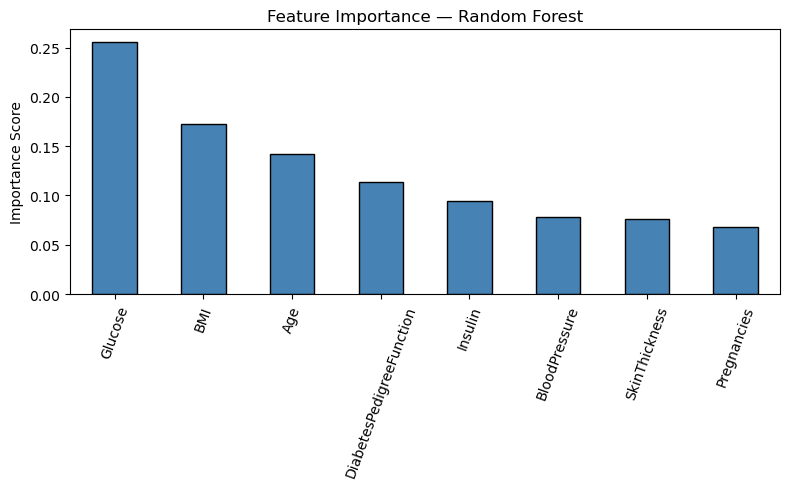

Glucose                     0.255717
BMI                         0.172842
Age                         0.142095
DiabetesPedigreeFunction    0.113560
Insulin                     0.093991
BloodPressure               0.077750
SkinThickness               0.076470
Pregnancies                 0.067575
dtype: float64


In [28]:
# getting feature importance from Random Forest
feature_importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

# plotting
plt.figure(figsize=(8,5))
feature_importance.plot(kind='bar', 
                         color='steelblue',
                         edgecolor='black')
plt.title('Feature Importance — Random Forest')
plt.ylabel('Importance Score')
plt.xticks(rotation=70)
plt.tight_layout()
plt.show()

print(feature_importance)

**observation — feature importance :**

* **Glucose (0.2557)**                --> strongest feature 
                                          confirms our EDA finding
                                          
* **BMI (0.1728)**                    --> second most important
                                          consistent with EDA 
                                          
* **Age (0.1421)**                    --> third most important 

* **DiabetesPedigreeFunction (0.1136)** --> meaningful contributor

* **Insulin (0.0940)**                --> moderate importance
                                          despite high variance

* **BloodPressure (0.0778)**          --> low importance
                                          consistent with EDA 
                                          
* **SkinThickness (0.0765)**          --> low importance
                                          consistent with EDA 
                                          
* **Pregnancies (0.0676)**            --> lowest importance

---

**feature selection decision :**

--> based on feature importance scores i will select 
    top 5 features for next round of modeling —

* Glucose                  --> 0.2557
* BMI                      --> 0.1728
* Age                      --> 0.1421
* DiabetesPedigreeFunction --> 0.1136
* Insulin                  --> 0.0940

**why i dropped these 3 features :**

* **BloodPressure**  --> importance only 0.0778 and 
                         weakest correlation with Outcome 
                         in EDA (0.17). not contributing enough.
                         
* **SkinThickness**  --> importance only 0.0765 and 
                         we already found data quality issues 
                         in this column during cleaning.
                         
* **Pregnancies**    --> lowest importance score 0.0676.
                         dropping it to simplify the model.

--> **running models again with these top 5 features 
    to see if accuracy improves.**

---
**Run Models on Top 5 Features**

--> lets now run all 4 models using only 
    the top 5 selected features and check 
    if accuracy improves.
    
--> selected features : Glucose, BMI, Age, 
    DiabetesPedigreeFunction, Insulin

In [29]:
# selecting top 5 features
top_features = ['Glucose', 'BMI', 'Age', 
                 'DiabetesPedigreeFunction', 'Insulin']

X_top = df[top_features]
y_top = df['Outcome']

# split again
X_train_top, X_test_top, y_train_top, y_test_top = train_test_split(
                            X_top, y_top,
                            test_size=0.2,
                            random_state=42)

# scale with minmax scaler
# using minmax because it performed better in previous round
X_train_top_scaled = minmax.fit_transform(X_train_top)
X_test_top_scaled = minmax.transform(X_test_top)

print("top 5 features selected and scaled")

top 5 features selected and scaled


In [30]:
top_results = {}

# 1] Logistic Regression
lr_top = LogisticRegression(class_weight='balanced',
                              max_iter=1000,
                              random_state=42)
lr_top.fit(X_train_top_scaled, y_train_top)
top_results['Logistic Regression'] = accuracy_score(
            y_test_top, lr_top.predict(X_test_top_scaled))

# 2] KNN
knn_top = KNeighborsClassifier()
knn_top.fit(X_train_top_scaled, y_train_top)
top_results['KNN'] = accuracy_score(
            y_test_top, knn_top.predict(X_test_top_scaled))

# 3] Decision Tree
dt_top = DecisionTreeClassifier(class_weight='balanced',
                                  random_state=42)
dt_top.fit(X_train_top_scaled, y_train_top)
top_results['Decision Tree'] = accuracy_score(
            y_test_top, dt_top.predict(X_test_top_scaled))

# 4] Random Forest
rf_top = RandomForestClassifier(class_weight='balanced',
                                  random_state=42)
rf_top.fit(X_train_top_scaled, y_train_top)
top_results['Random Forest'] = accuracy_score(
            y_test_top, rf_top.predict(X_test_top_scaled))

print("accuracy with top 5 features :")
for model, acc in top_results.items():
    print(f"  {model:25} --> {acc:.4f}")

accuracy with top 5 features :
  Logistic Regression       --> 0.7078
  KNN                       --> 0.7403
  Decision Tree             --> 0.7338
  Random Forest             --> 0.7338


**observation — top 5 features results :**

* **Logistic Regression** --> 0.7078
                          --> same as minmax round
                          --> feature selection did not 
                              change it much
                          
* **KNN**                 --> 0.7403
                          --> dropped from 0.7338 baseline
                              to 0.7403 with top features 
                          --> still performing well after 
                              feature selection
                          
* **Decision Tree**       --> 0.7338
                          --> same as baseline
                          --> consistent but not improving
                          
* **Random Forest**       --> 0.7338
                          --> dropped from 0.7597 to 0.7338
                          --> removing 3 features actually 
                              hurt Random Forest 
                          --> Random Forest works better 
                              with all features because it 
                              selects best features internally

--> **interesting finding : feature selection helped KNN 
    but hurt Random Forest.**
    
--> **best accuracy overall is still Random Forest 
    with all 8 features at 0.7597**
    
--> **this tells us that for Random Forest, 
    keeping all features is better because 
    the algorithm handles feature selection 
    on its own internally.**

---
**Additional Method — Cross Validation**

--> one more way to better evaluate our model 
    is using cross validation.
    
--> instead of one single train test split, 
    cross validation splits data into 5 parts 
    and trains the model 5 times on different splits.
    
--> this gives a more reliable accuracy score 
    that does not depend on one lucky split.

In [32]:
from sklearn.model_selection import cross_val_score

# cross validation on best model with top 5 features
cv_scores = cross_val_score(
    RandomForestClassifier(class_weight='balanced',
                            random_state=42),
    X_top, y_top,
    cv=5,
    scoring='accuracy'
)

print("cross validation scores :", cv_scores)
print("mean cv accuracy        :", cv_scores.mean().round(4))
print("std of cv scores        :", cv_scores.std().round(4))

cross validation scores : [0.75324675 0.72727273 0.76623377 0.81045752 0.71895425]
mean cv accuracy        : 0.7552
std of cv scores        : 0.0325


**observation — cross validation results :**

* **cv scores :** 0.7532, 0.7273, 0.7662, 0.8105, 0.7190

* **mean cv accuracy : 0.7552**

* **std of cv scores : 0.0325**

--> std of 0.0325 is quite low which means 
    model is stable across different data splits ✓
    
--> scores range from 0.7190 to 0.8105 —
    variation is acceptable for a dataset 
    of this size (768 rows)
    
--> mean cv accuracy of 0.7552 is very close 
    to our test accuracy of 0.7597 —
    this confirms model is not overfitting ✓
    
--> model is learning real patterns from data 
    and not just memorizing training data

---

**final model decision :**

--> we will go with **Random Forest using all 8 features**
    as our final model because —

* highest test accuracy of 0.7597
* most stable across all experiment rounds
* cross validation confirms no overfitting
* std of only 0.0325 confirms consistent performance
* best suited for imbalanced medical data
* handles feature selection internally

--> **Random Forest is our best and final model.**